In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('ww2_deaths.csv')
df.head()

,Country,Military_Deaths,Total_deaths,Civilian_deaths
0,Albania,30000,30200,200
1,Australia,39800,40500,700
2,Austria,261000,384700,123700
3,Belgium,12100,86100,74000
4,Brazil,1000,2000,1000


In [3]:
df.describe()

,Military_Deaths,Total_deaths,Civilian_deaths
count,4.000000e+01,4.000000e+01,4.000000e+01
mean,6.429900e+05,1.959280e+06,1.316290e+06
std,1.961503e+06,4.989075e+06,3.324132e+06
min,0.000000e+00,2.000000e+03,0.000000e+00
25%,7.500000e+02,4.417500e+04,2.750000e+03
50%,2.750000e+04,3.490000e+05,1.396500e+05
75%,2.707500e+05,8.747500e+05,6.067500e+05
max,1.070000e+07,2.400000e+07,1.600000e+07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Country          40 non-null     object
 1   Military_Deaths  40 non-null     int64 
 2   Total_deaths     40 non-null     int64 
 3   Civilian_deaths  40 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.4+ KB


In [5]:
df.columns

Index(['Country', 'Military_Deaths', 'Total_deaths', 'Civilian_deaths'], dtype='object')

In [6]:
df.isnull().sum()

,0
Country,0
Military_Deaths,0
Total_deaths,0
Civilian_deaths,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.groupby('Country')['Military_Deaths'].sum().sort_values(ascending=False)

,Military_Deaths
Country,
Russia,10700000
Germany,5533000
China,4000000
Japan,2120000
Yugoslavia,446000
United States,416800
United Kingdom,383600
Italy,301400
Romania,300000


In [9]:
df['Country'].value_counts().sum()

np.int64(40)

<Axes: title={'center': 'Military Deaths in WW2'}, xlabel='Country', ylabel='Military Deaths'>

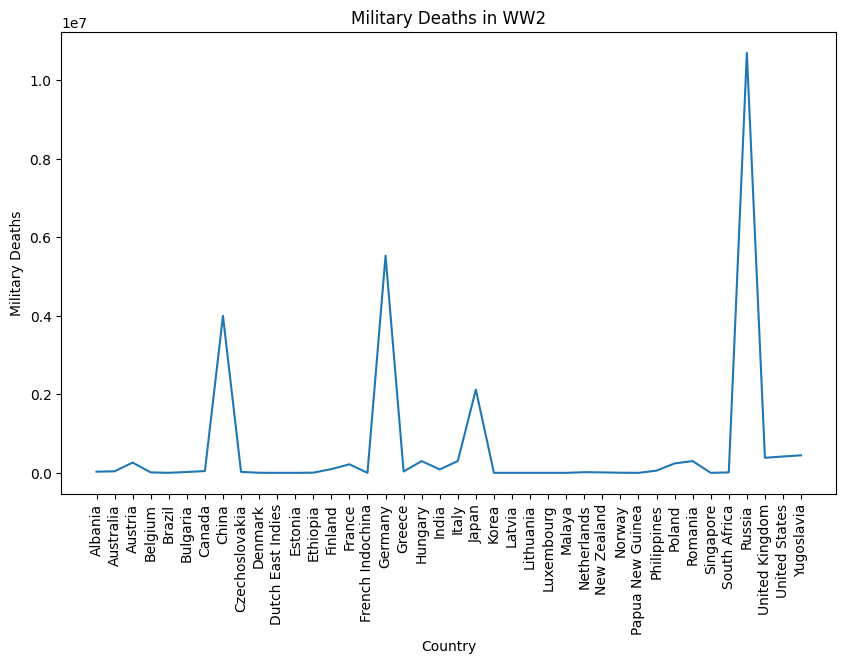

In [10]:
plt.figure(figsize=(10,6))
plt.title('Military Deaths in WW2')
plt.xlabel('Country')
plt.ylabel('Military Deaths')
plt.xticks(rotation=90)
sns.lineplot(x='Country',y='Military_Deaths',data=df)

<Axes: title={'center': 'Civillian Deaths in WW2'}, xlabel='Country', ylabel='Civilian Deaths'>

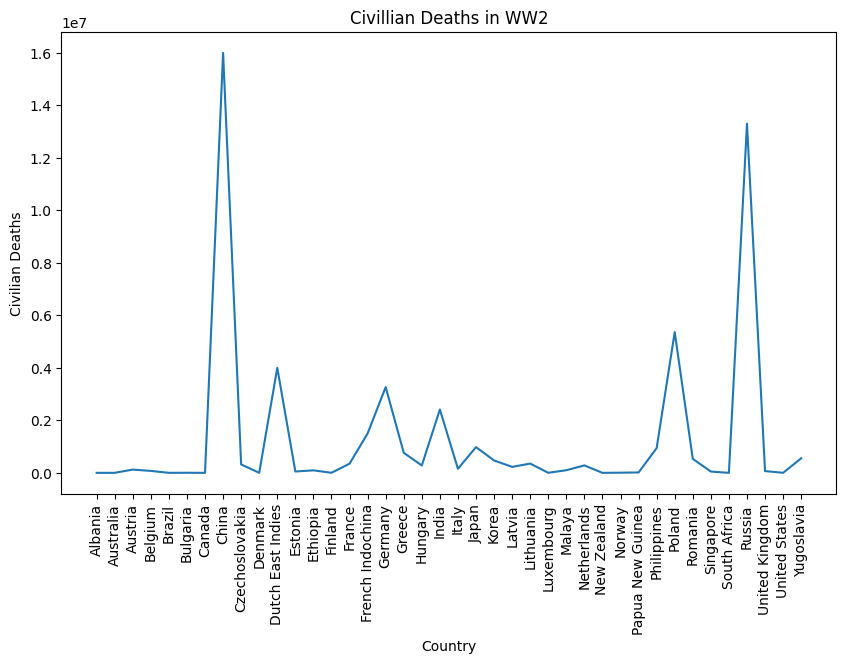

In [11]:
plt.figure(figsize=(10,6))
plt.title('Civillian Deaths in WW2')
plt.xlabel('Country')
plt.ylabel('Civilian Deaths')
plt.xticks(rotation=90)
sns.lineplot(x='Country',y='Civilian_deaths',data=df)

In [12]:
df.groupby('Country')['Civilian_deaths'].sum().sort_values(ascending=False)

,Civilian_deaths
Country,
China,16000000
Russia,13300000
Poland,5360000
Dutch East Indies,4000000
Germany,3267000
India,2413000
French Indochina,1500000
Japan,980000
Philippines,943000


In [38]:
ddf=df[df['Total_deaths'] > 10000000]
display(ddf)

,Country,Military_Deaths,Total_deaths,Civilian_deaths
7,China,4000000,20000000,16000000
36,Russia,10700000,24000000,13300000


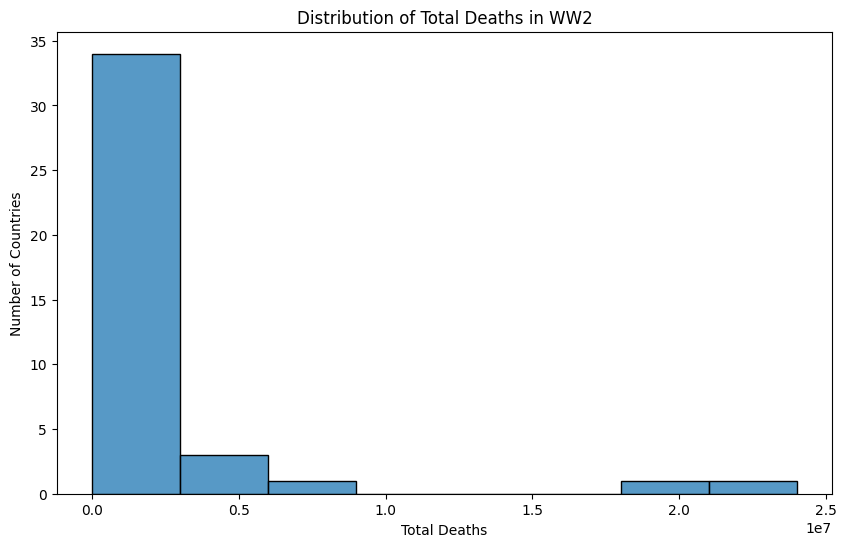

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_deaths'], bins=8, kde=False)
plt.title('Distribution of Total Deaths in WW2')
plt.xlabel('Total Deaths')
plt.ylabel('Number of Countries')
plt.show()

The histogram of 'Total Deaths in WW2' reveals a heavily **right-skewed distribution**. This means that while most countries experienced significantly lower total death counts, a few nations suffered an exceptionally high number of casualties. The most prominent outliers are **Russia with 24,000,000 total deaths** and **China with 20,000,000 total deaths**.

These extreme figures are not data quality issues but grim reflections of the immense historical disaster and the brutal realities of World War II. For instance, in Russia, military deaths (10,700,000) slightly outnumbered civilian deaths (13,300,000, adjusted for the USSR total), whereas in China, civilian deaths (16,000,000) far surpassed military deaths (4,000,000), highlighting different aspects of the conflict's devastating impact on these nations.

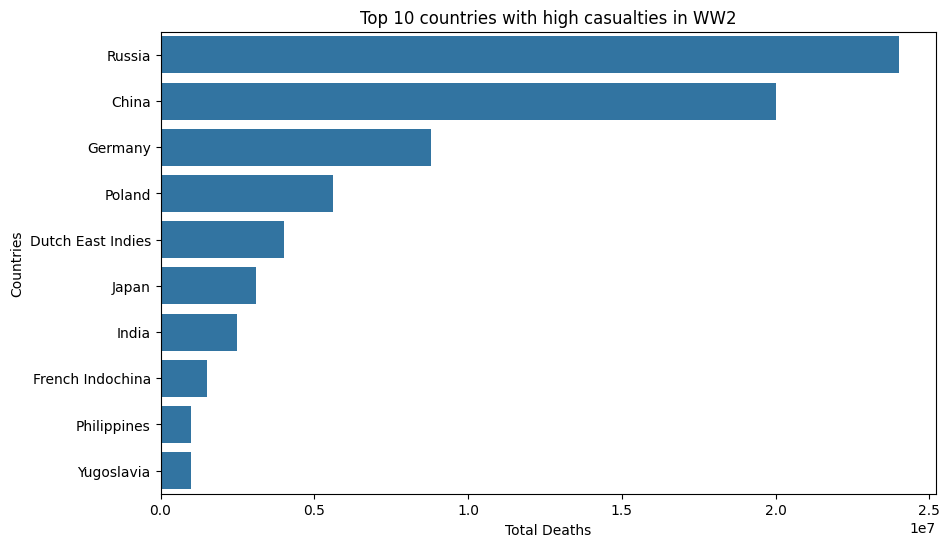

In [39]:
plt.figure(figsize=(10, 6))
plt.title('Top 10 countries with high casualties in WW2')
plt.xlabel('Total Deaths')
plt.ylabel('Countries')
sns.barplot(x='Total_deaths', y='Country', data=df.nlargest(10, 'Total_deaths'))
plt.show()

Here the **Barplot** shows **top 10 countries** from the dataset who had most casualties, **Top 3** are:
1. Russia
2. China
3. Germany

It confirms what histogram showed.

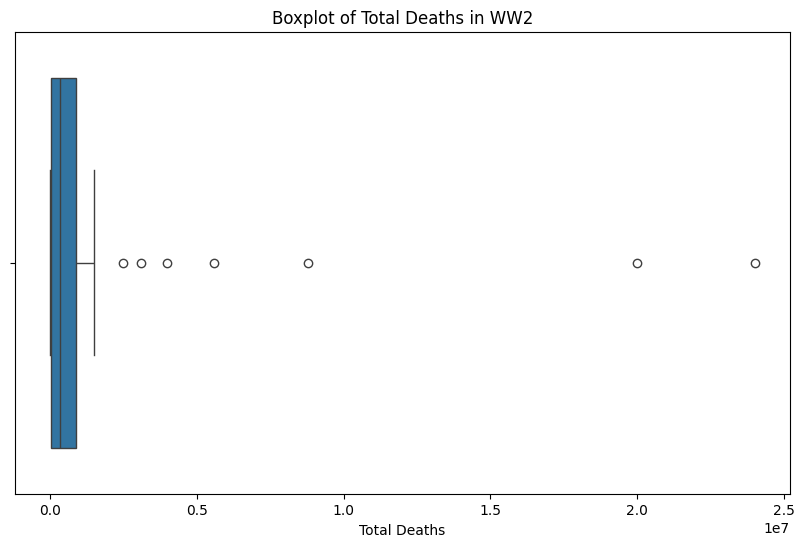

In [43]:
plt.figure(figsize=(10, 6))
plt.xlabel('Total Deaths')
sns.boxplot(x='Total_deaths', data=df)
plt.title('Boxplot of Total Deaths in WW2')
plt.show()

In [48]:
Q1=df['Total_deaths'].quantile(0.25)
Q3=df['Total_deaths'].quantile(0.75)
print(f'Q1: {Q1}\nQ3: {Q3}')
IQR= Q3-Q1
print(f'IQR: {IQR}')
uper_wisker=Q3+1.5*IQR
print(f'uper_wisker: {uper_wisker}')

Q1: 44175.0
Q3: 874750.0
IQR: 830575.0
uper_wisker: 2120612.5


In [49]:
outliers_df = df[df['Total_deaths'] > uper_wisker]
display(outliers_df)

,Country,Military_Deaths,Total_deaths,Civilian_deaths
7,China,4000000,20000000,16000000
10,Dutch East Indies,0,4000000,4000000
16,Germany,5533000,8800000,3267000
19,India,87000,2500000,2413000
21,Japan,2120000,3100000,980000
32,Poland,240000,5600000,5360000
36,Russia,10700000,24000000,13300000


A **boxplot** is a great way to visualize the distribution of numerical data and spot any unusual values, called **outliers**.

*   The **box** in the middle shows where the middle 50% of the data lies. The line inside the box is the **median** (the middle value).
*   The ends of the box represent the **first quartile (Q1)** and **third quartile (Q3)**. Q1 means 25% of the data is below this value, and Q3 means 75% of the data is below this value.
*   The **whiskers** extending from the box show the range of the data, excluding the outliers. They typically extend up to 1.5 times the **Interquartile Range (IQR)** from Q1 and Q3.
*   **Outliers** are plotted as individual points beyond the whiskers.

In our case, for 'Total Deaths':
*   **Q1: 44,175**
*   **Q3: 874,750**
*   **IQR: 830,575** (the spread of the middle 50% of countries)
*   **Upper Whisker: 2,120,612.5**

The boxplot clearly flags several countries as extreme outliers, which are those with 'Total_deaths' exceeding the upper whisker value. These countries are:

*   **China** (20,000,000 deaths)
*   **Dutch East Indies** (4,000,000 deaths)
*   **Germany** (8,800,000 deaths)
*   **India** (2,500,000 deaths)
*   **Japan** (3,100,000 deaths)
*   **Poland** (5,600,000 deaths)
*   **Russia** (24,000,000 deaths)

These outliers reinforce what we saw in the histogram: a small number of countries experienced vastly higher casualty rates in WW2 compared to the majority.

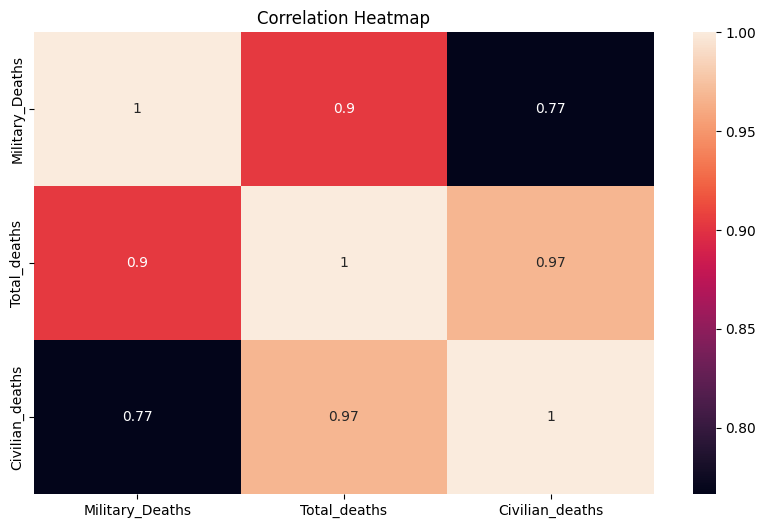

In [55]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()



This heatmap shows how closely different types of deaths are related. The numbers (from -1 to 1) and colors tell us:

*   **Close to 1 (darker color):** Means they tend to go up and down together. For example, if 'Military Deaths' are high, 'Total Deaths' are also high.
*   **Close to 0 (lighter color):** Means they don't really affect each other much.

Here, we see very strong connections:

*   **Total Deaths** are highly linked to both **Military Deaths** and **Civilian Deaths**. This makes sense, as these are the main parts of total casualties.
*   **Military Deaths** and **Civilian Deaths** also have a strong positive link, meaning countries with many military casualties often had many civilian casualties too, showing the widespread impact of the war.